In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt


from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

In [5]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17


#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size)

transform_seq.to(device)


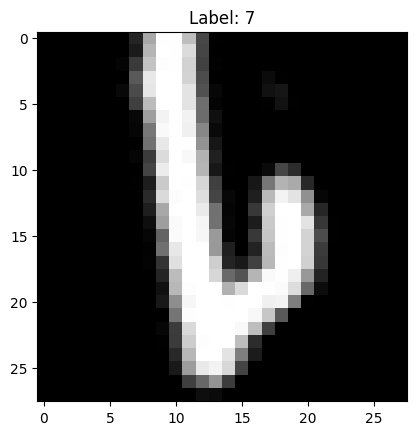

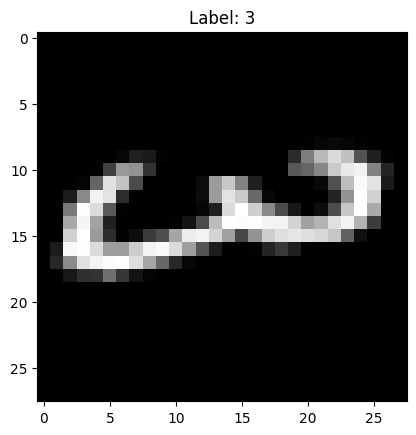

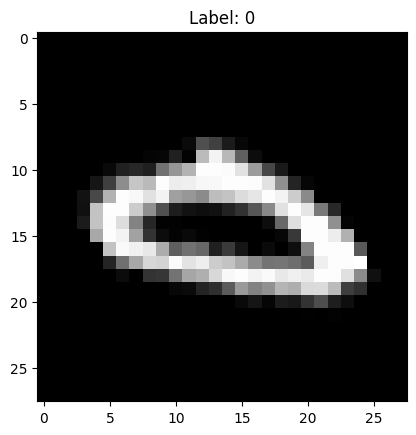

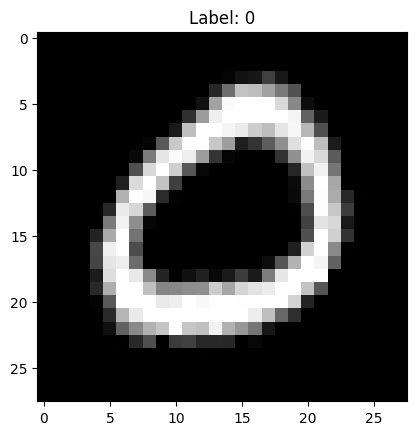

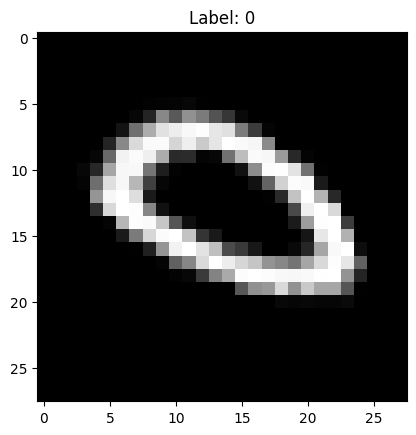

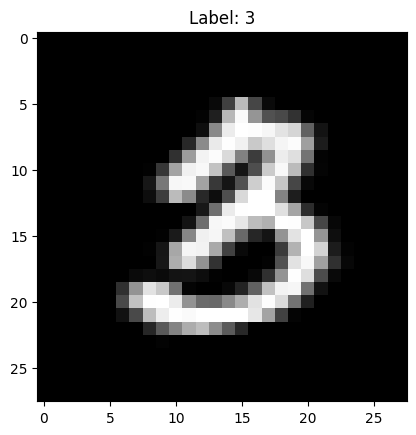

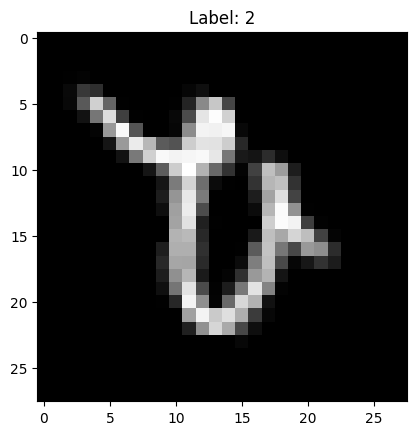

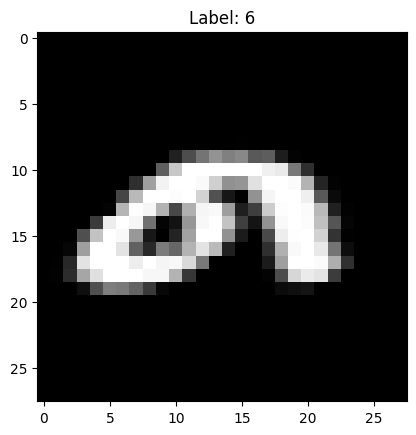

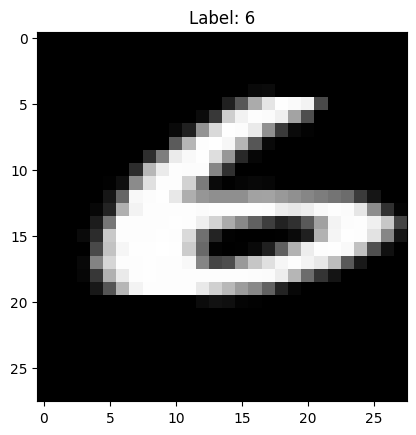

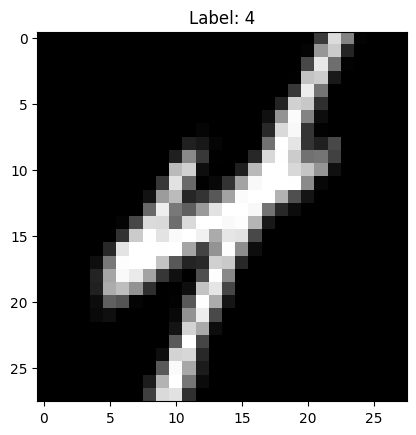

In [6]:
#plot images
for i in range(10):
    img, label = dataset_test[i]
    img = img.to(device)
    img = img.unsqueeze(0)
    img = img.squeeze(0).cpu().numpy()
    plt.imshow(img[0], cmap='gray')
    plt.title(f'Label: {label}')
    plt.show()


In [7]:
transforms_inverted = transform_seq.get_inverted_sequence()

In [8]:
dataset_test_inverted = AffineTransformDataset(dataset_test_pre,create_sampler(transforms_inverted),return_transformation=False,batch_size=batch_size)

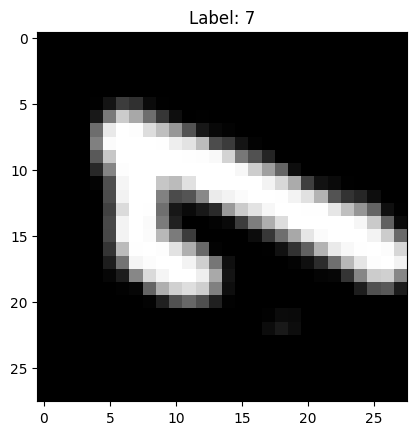

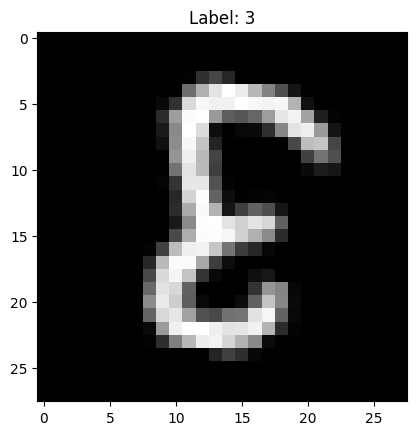

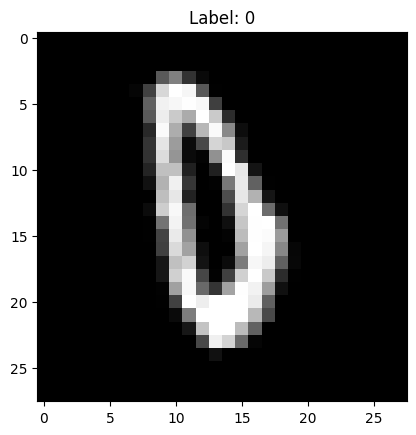

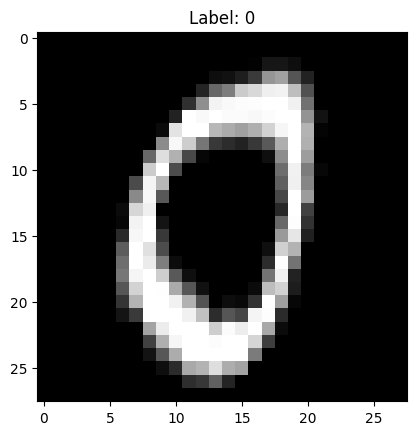

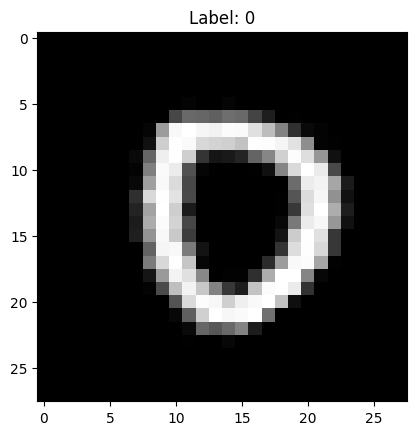

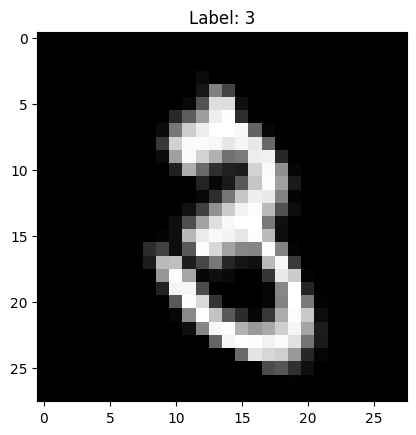

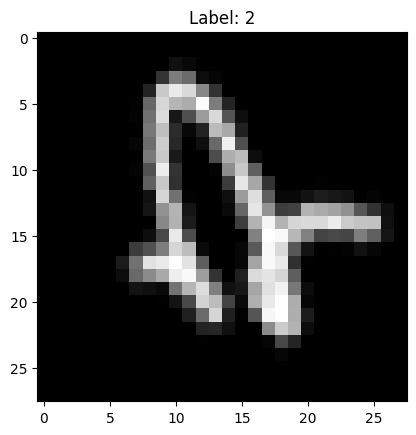

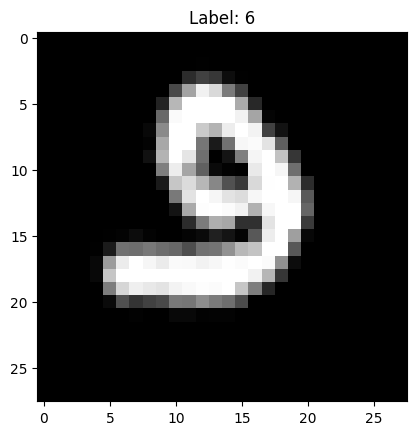

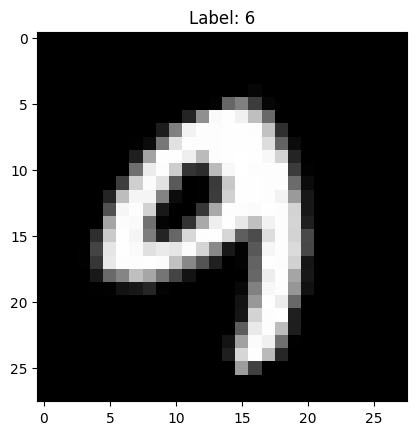

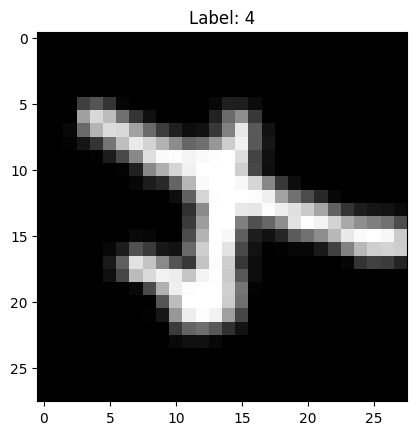

In [9]:
for i in range(10):
    img, label = dataset_test_inverted[i]
    img = img.to(device)
    img = img.unsqueeze(0)
    img = img.squeeze(0).cpu().numpy()
    plt.imshow(img[0], cmap='gray')
    plt.title(f'Label: {label}')
    plt.show()

In [10]:
transforms_opt = transform_seq.get_version_optimized_for_prediction()

In [11]:
dataset_test_opt = AffineTransformDataset(dataset_test_pre, create_sampler(transforms_opt), return_transformation=False, batch_size=batch_size)


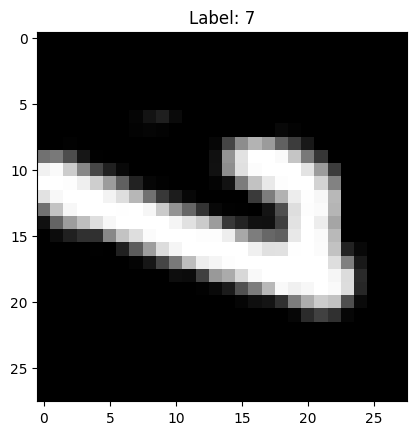

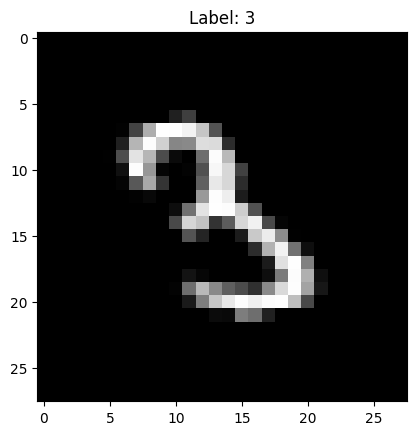

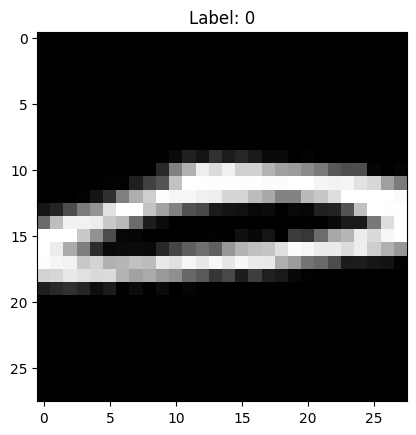

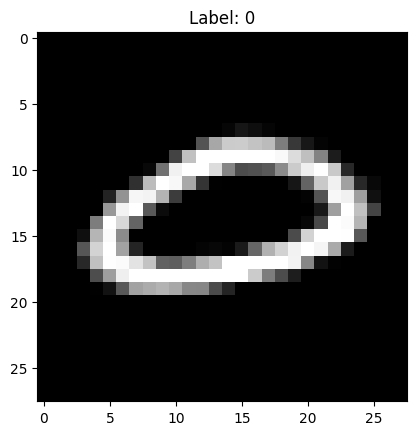

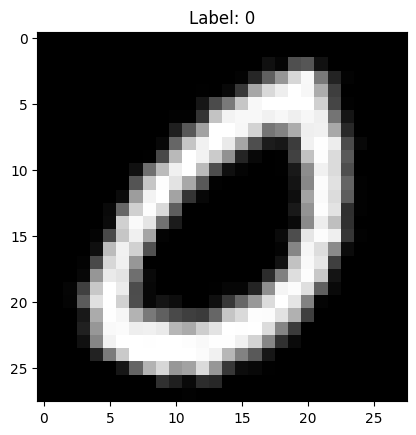

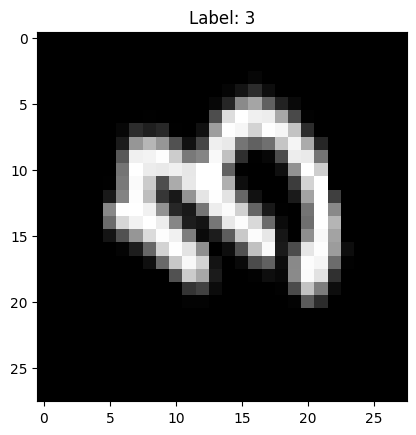

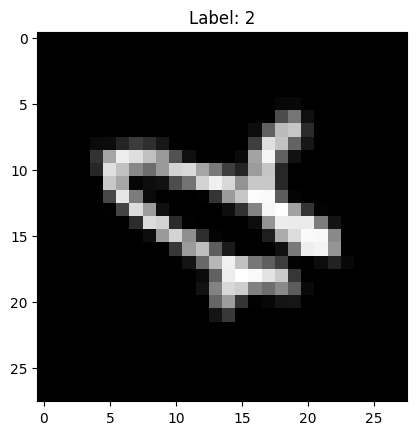

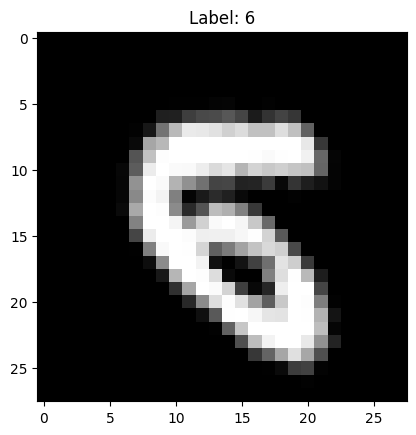

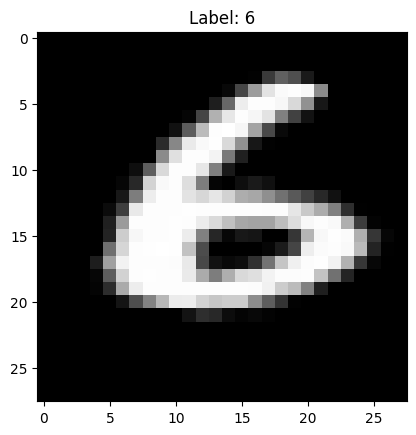

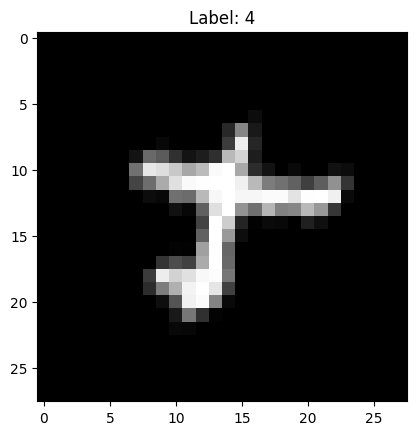

In [12]:
for i in range(10):
    img, label = dataset_test_opt[i]
    img = img.to(device)
    img = img.unsqueeze(0)
    img = img.squeeze(0).cpu().numpy()
    plt.imshow(img[0], cmap='gray')
    plt.title(f'Label: {label}')
    plt.show()

In [13]:
sampler_param = create_parameter_sampler(transform_seq)

In [14]:
sampler_param2 = create_parameter_sampler(transforms_opt)


In [15]:
for i in range(20):
    random_param= sampler_param(1)
    transformed_params =TransformSequence.transform_params_between_sequences(random_param,transform_seq, transforms_opt)
    matrix1 = transform_seq(random_param)
    matrix2 = transforms_opt(transformed_params)
    dif = torch.abs(matrix1 - matrix2).max()
    print(f"Max difference between matrices: {dif.item()}")


Max difference between matrices: 0.0
Max difference between matrices: 5.960464477539063e-08
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 0.0


In [18]:
for i in range(20):
    random_param= sampler_param2(1)
    transformed_params =TransformSequence.transform_params_between_sequences(random_param,transforms_opt, transform_seq)
    matrix1 = transform_seq(transformed_params)
    matrix2 = transforms_opt(random_param)
    dif = torch.abs(matrix1 - matrix2).max()
    print(f"Max difference between matrices: {dif.item()}")


Max difference between matrices: 1.7601996660232544e-07
Max difference between matrices: 7.450580596923828e-08
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 8.940696716308594e-08
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 0.0
Max difference between matrices: 3.725290298461914e-08
Max difference between matrices: 8.940696716308594e-08
Max difference between matrices: 5.960464477539063e-08
Max difference between matrices: 2.980232238769531e-07
Max difference between matrices: 2.9802322387695312e-08
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 1.2665987014770508e-07
Max difference between matrices: 0.0
Max difference between matrices: 0.0
Max difference between matrices: 1.1920928955078125e-07
Max difference between matrices: 1.4901161193847656e-07
Max difference between matrices: 5.960464477539063e-08
Max difference between matrices: 1.341104507446289e-07
M